Unique values in 'Attack_type': [ 3 10 11  0  1  2  4  5  6  7  8  9]
Data type of 'Attack_type': int32
y_train type: int32
y_test type: int32
Cross-validation scores: [0.99624346 0.99593888 0.99578659 0.99543101 0.99568484]
Mean CV score: 0.9958169563515847
=== Training Set Evaluation ===
Accuracy: 0.9978780217883504

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99      6172
           1       0.96      0.97      0.97       434
           2       1.00      1.00      1.00     75762
           3       1.00      1.00      1.00      3275
           4       1.00      0.81      0.89        31
           5       1.00      0.88      0.94        25
           6       1.00      1.00      1.00      1607
           7       1.00      1.00      1.00       782
           8       1.00      0.98      0.99      2101
           9       1.00      1.00      1.00      1626
          10       1.00      0.98      0.99      6483
      

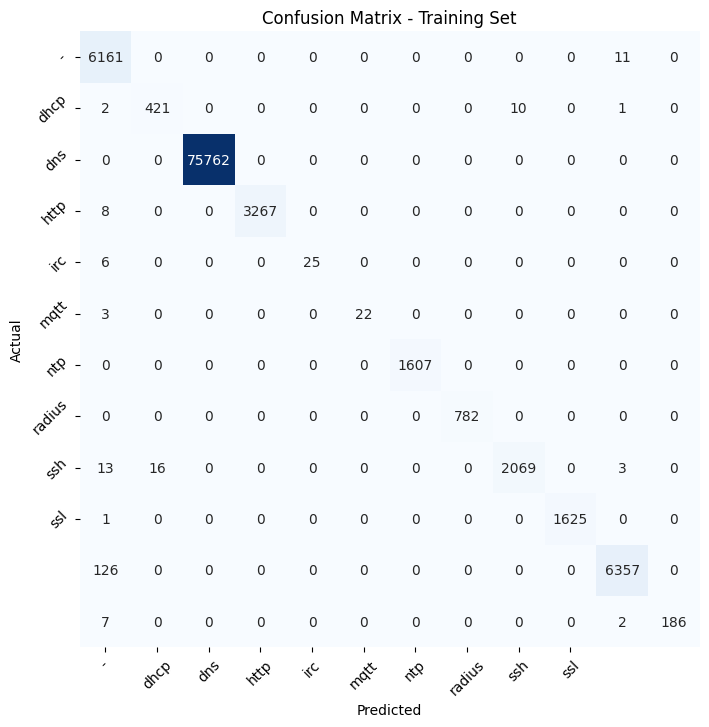


=== Test Set Evaluation ===
Accuracy: 0.9959389213775178

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98      1578
           1       0.95      0.92      0.93       100
           2       1.00      1.00      1.00     18897
           3       1.00      1.00      1.00       871
           4       1.00      0.67      0.80         6
           5       1.00      0.67      0.80         3
           6       1.00      1.00      1.00       393
           7       1.00      1.00      1.00       220
           8       0.99      0.97      0.98       489
           9       1.00      0.99      1.00       384
          10       0.99      0.97      0.98      1625
          11       0.98      0.84      0.91        58

    accuracy                           1.00     24624
   macro avg       0.99      0.92      0.95     24624
weighted avg       1.00      1.00      1.00     24624


Confusion Matrix:
 [[ 1569     0     0     0     

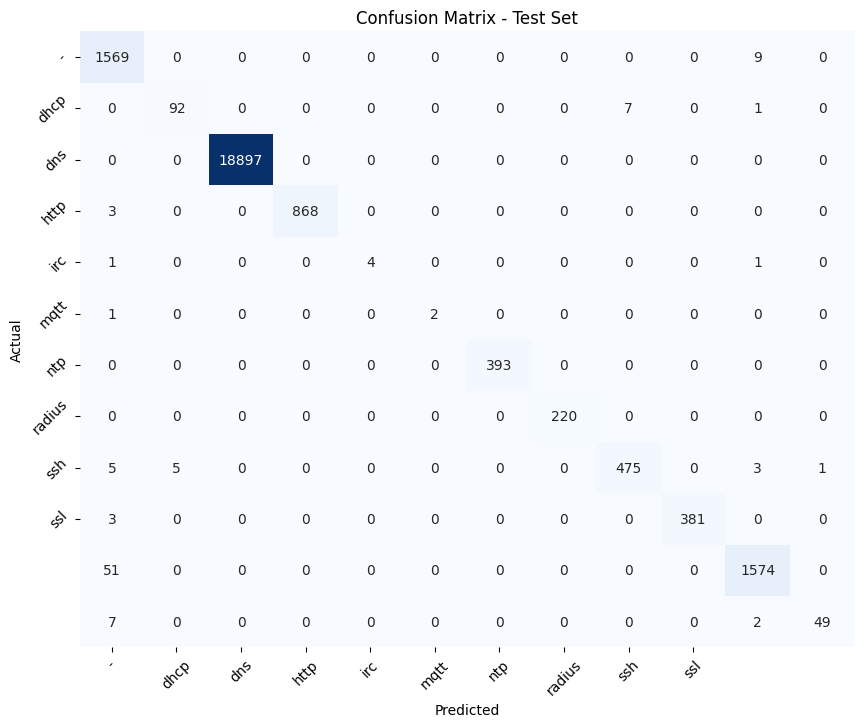

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load Data
data_train = pd.read_csv("RT_IOT2022.csv")

# Drop irrelevant columns and handle missing values
irrelevant_cols = ['id.orig_p', 'id.resp_p']
data_train.drop(columns=irrelevant_cols, inplace=True, errors='ignore')

# Handle missing values
data_train.dropna(inplace=True)

# Encode Target Column ('Attack_type') - Label Encoding
if 'Attack_type' in data_train.columns:
    # Initialize LabelEncoder for the Attack_type column
    encoder = LabelEncoder()
    data_train['Attack_type'] = encoder.fit_transform(data_train['Attack_type'])
    
    # Check unique values and data type
    print("Unique values in 'Attack_type':", data_train['Attack_type'].unique())
    print("Data type of 'Attack_type':", data_train['Attack_type'].dtype)
else:
    raise ValueError("'Attack_type' column is missing in the dataset!")

# Ensure 'Attack_type' is of integer type
data_train['Attack_type'] = data_train['Attack_type'].astype(int)

# Check if the target variable is continuous
if data_train['Attack_type'].dtype != 'int':
    raise ValueError("The target variable 'Attack_type' is not of integer type. Please check the encoding.")

# Encode Categorical Features
categorical_cols = ['proto', 'service']
for col in categorical_cols:
    if col in data_train.columns:
        data_train[col] = encoder.fit_transform(data_train[col].astype(str))
    else:
        print(f"Warning: Column '{col}' is missing in the dataset!")

# Feature Engineering
data_train['total_packets'] = data_train['fwd_pkts_tot'] + data_train['bwd_pkts_tot']
data_train['total_payload'] = data_train['fwd_pkts_payload.tot'] + data_train['bwd_pkts_payload.tot']
data_train['flow_duration_per_packet'] = data_train['flow_duration'] / (data_train['total_packets'] + 1e-6)

# Scale Numerical Features
num_cols = data_train.select_dtypes(include=['float64', 'int64']).columns
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data_train[num_cols])
data_train[num_cols] = scaled_features

# Split Data into Training and Testing Sets
X = data_train.drop(columns=['Attack_type'])
y = data_train['Attack_type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the types of y_train and y_test
print("y_train type:", y_train.dtype)
print("y_test type:", y_test.dtype)

# Apply PCA to Reduce Features to 20 Dimensions
pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Initialize and Train Random Forest Classifier
rf_classifier = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    min_samples_split=5, 
    min_samples_leaf=2, 
    random_state=42
)
rf_classifier.fit(X_train_pca, y_train)

# Cross-validation to mitigate overfitting
cv_scores = cross_val_score(rf_classifier, X_train_pca, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV score:", np.mean(cv_scores))

# Make Predictions
y_train_pred = rf_classifier.predict(X_train_pca)
y_test_pred = rf_classifier.predict(X_test_pca)

# Training Set Evaluation
print("=== Training Set Evaluation ===")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

# Visualize Training Set Confusion Matrix
conf_matrix_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix_train, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("Confusion Matrix - Training Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

# Test Set Evaluation
print("\n=== Test Set Evaluation ===")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

# Visualize Test Set Confusion Matrix
conf_matrix_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

In [3]:
import numpy as np

# Print explained variance of each component
print("Explained Variance Ratio for each component:")
print(pca.explained_variance_ratio_)

# Print cumulative explained variance
print("Cumulative Explained Variance:")
print(np.cumsum(pca.explained_variance_ratio_))


Explained Variance Ratio for each component:
[0.21069959 0.15290384 0.09899074 0.08627956 0.07539636 0.04183277
 0.03186159 0.02724835 0.02465952 0.02402804 0.02310449 0.02063992
 0.01993175 0.01793035 0.01570952 0.01350615 0.01255843 0.01156633
 0.01018651 0.00946337]
Cumulative Explained Variance:
[0.21069959 0.36360344 0.46259417 0.54887374 0.6242701  0.66610286
 0.69796445 0.7252128  0.74987233 0.77390037 0.79700485 0.81764477
 0.83757653 0.85550688 0.8712164  0.88472255 0.89728098 0.90884731
 0.91903382 0.92849719]


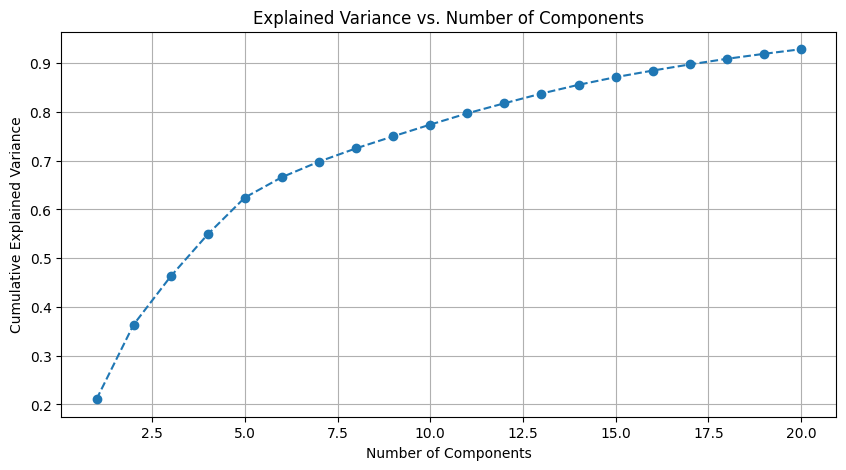

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Number of Components")
plt.grid()
plt.show()


In [5]:
import pandas as pd

# Get feature importance in each principal component
pca_components = pd.DataFrame(pca.components_, columns=X.columns, index=[f"PC{i+1}" for i in range(20)])

# Display top 5 principal components
print(pca_components.head())


     Unnamed: 0     proto   service  flow_duration  fwd_pkts_tot  \
PC1   -0.064625 -0.002975  0.271524       0.087470      0.138120   
PC2    0.059651  0.003887 -0.224027       0.008193      0.081739   
PC3    0.021431  0.004993 -0.145665       0.315143      0.226446   
PC4    0.012894  0.002483  0.082042       0.144278      0.132300   
PC5    0.127086 -0.081472 -0.125166       0.012412      0.003049   

     bwd_pkts_tot  fwd_data_pkts_tot  bwd_data_pkts_tot  fwd_pkts_per_sec  \
PC1      0.165195           0.074176           0.157746         -0.057464   
PC2      0.217915           0.028615           0.223062          0.054731   
PC3     -0.037964           0.257535          -0.043674          0.014402   
PC4     -0.078140           0.161922          -0.089245          0.006718   
PC5     -0.000341           0.003237          -0.005547          0.307248   

     bwd_pkts_per_sec  ...  idle.max  idle.tot  idle.avg  idle.std  \
PC1         -0.057471  ...  0.133799  0.086541  0.130193  

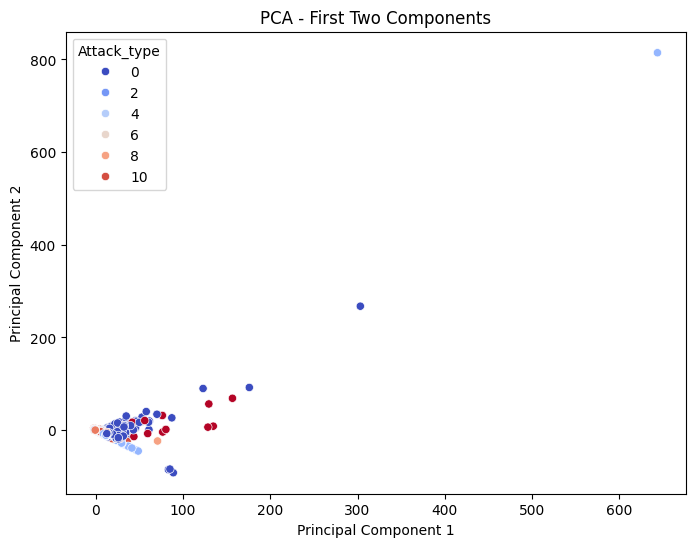

In [6]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette="coolwarm")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - First Two Components")
plt.show()


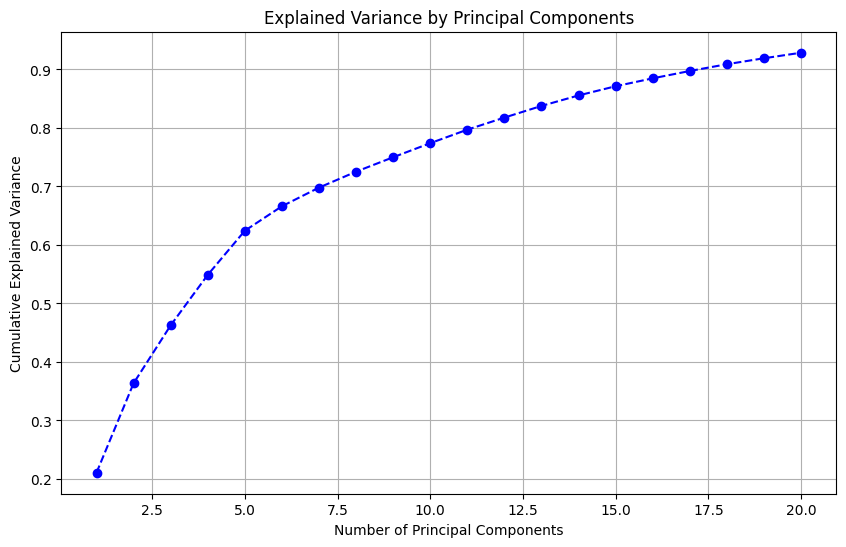

In [7]:
# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='b')
plt.title("Explained Variance by Principal Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()



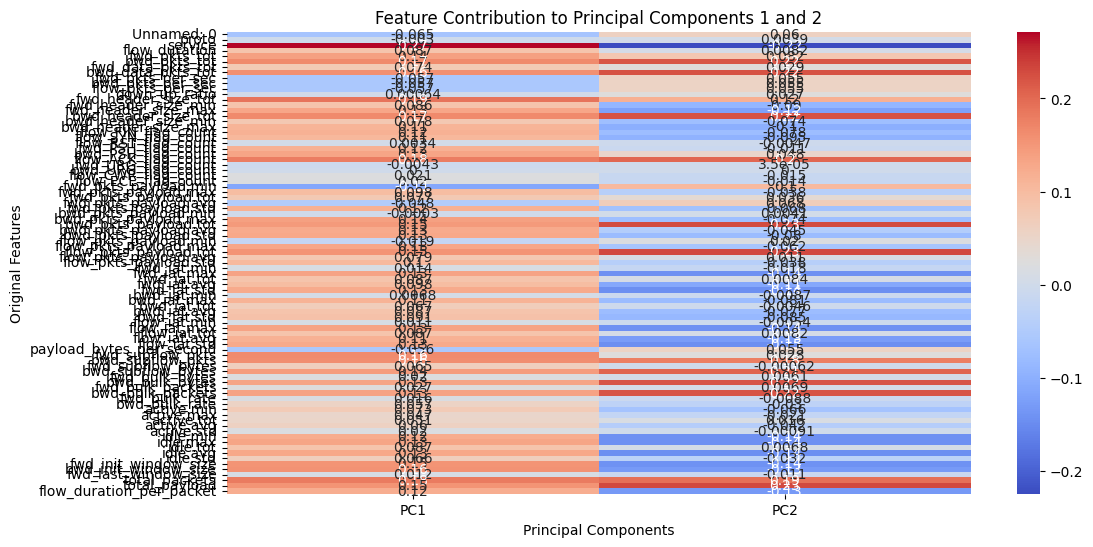

In [8]:
# Contribution of original features to the first two components
components = pd.DataFrame(pca.components_, columns=X.columns)

plt.figure(figsize=(12, 6))
sns.heatmap(components.iloc[:2].T, annot=True, cmap="coolwarm", xticklabels=["PC1", "PC2"], yticklabels=X.columns)
plt.title("Feature Contribution to Principal Components 1 and 2")
plt.xlabel("Principal Components")
plt.ylabel("Original Features")
plt.show()


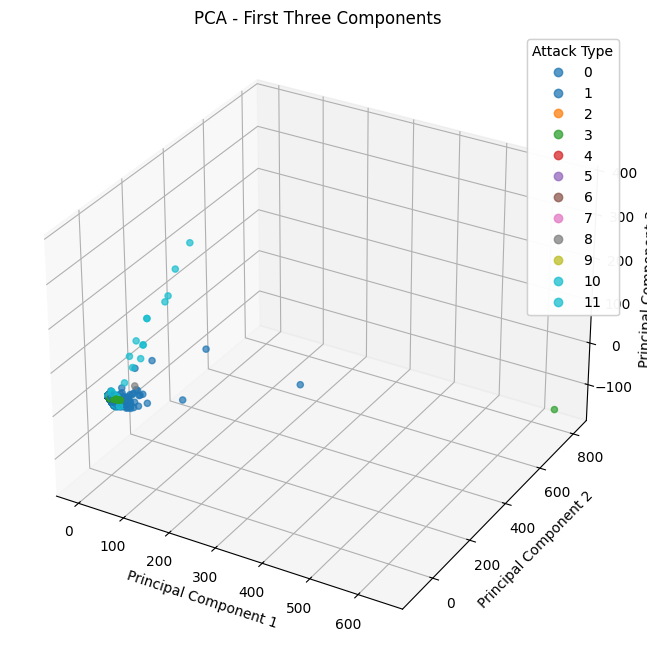

In [9]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    X_train_pca[:, 0], 
    X_train_pca[:, 1], 
    X_train_pca[:, 2], 
    c=y_train, 
    cmap="tab10", 
    alpha=0.7
)
legend = ax.legend(*scatter.legend_elements(), title="Attack Type")
ax.add_artist(legend)
ax.set_title("PCA - First Three Components")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
plt.show()
